In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.multicomp as multi

# Loading Data

In [1]:
# Load only averages of the evaluation results 
Averages = False
if (Averages):
    results_dataframe = pd.read_csv('./Results.csv')
else:
    # Load all of the evaluation results 
    results_mit = pd.read_csv('./data/results/evaluation_results_mit.csv')
    results_mit['Unnamed: 0'] = 'External ECGs (n = 44)'
    results_mit.rename(columns={'Unnamed: 0': 'Cohort'}, inplace=True)
    results_both = pd.read_csv('./data/results/evaluation_results_both.csv')
    results_both['Unnamed: 0'] = 'MRI (n = 33)'
    results_both.rename(columns={'Unnamed: 0': 'Cohort'}, inplace=True)
    results_15 = pd.read_csv('./data/results/evaluation_results_15.csv')
    results_15['Unnamed: 0'] = '1.5 Tesla MRI (n = 25)'
    results_15.rename(columns={'Unnamed: 0': 'Cohort'}, inplace=True)
    results_3 = pd.read_csv('./data/results/evaluation_results_3.csv')
    results_3['Unnamed: 0'] = '3 Tesla MRI (n = 8)'
    results_3.rename(columns={'Unnamed: 0': 'Cohort'}, inplace=True)

    # Combine all evaluation results into one dataframe 
    results_dataframe = pd.concat([results_mit, results_both, results_15, results_3], ignore_index=True)

    # Rename columns and rows for plotting and paper 
    column_rename_mapping = {
        "detection_type": "R-Peak Detection Method",
        "accuracy": "Accuracy (%)",
        "MAE": "Mean Absolute Error (ms)",
        "sensitivity": "Sensitivity (%)",
        "specificity": "Specificity (%)",
        "ppv": "Positive Predictive Value (%)",
        "fpr": "False Positive Rate (%)",
        "F1": "F1 Score (%)"
    }
    results_dataframe.rename(columns=column_rename_mapping, inplace=True)

    # Replace 'Trigger' with 'Proprietary VCG Trigger' in the 'R-Peak Detection Method' column
    results_dataframe['R-Peak Detection Method'] = results_dataframe['R-Peak Detection Method'].replace('Trigger', 'Proprietary VCG Trigger')

    # Turn decimals to percentages
    columns_to_multiply = ["Accuracy (%)", "Sensitivity (%)", "Specificity (%)", "Positive Predictive Value (%)", "False Positive Rate (%)", "F1 Score (%)"]
    results_dataframe[columns_to_multiply] = results_dataframe[columns_to_multiply].apply(lambda x: x * 100)

    # Turn s to ms for Mean Absolute Error (ms)
    results_dataframe['Mean Absolute Error (ms)'] = results_dataframe['Mean Absolute Error (ms)'].apply(lambda x: x * 1000)

# Table of Means +/- Stds

In [4]:
# Calculate mean and standard deviation
means = results_dataframe.groupby(['Cohort', 'R-Peak Detection Method'])[['F1 Score (%)', 'Sensitivity (%)', 'Positive Predictive Value (%)', 'Accuracy (%)', 'Mean Absolute Error (ms)', 'Specificity (%)', 'False Positive Rate (%)']].mean()
stds = results_dataframe.groupby(['Cohort', 'R-Peak Detection Method'])[['F1 Score (%)', 'Sensitivity (%)', 'Positive Predictive Value (%)', 'Accuracy (%)', 'Mean Absolute Error (ms)', 'Specificity (%)', 'False Positive Rate (%)']].std()

# Combine mean and standard deviation in the format: mean +/- std
results_dataframe_summarized = means.astype(str) + " +/- " + stds.round(2).astype(str)
results_dataframe_summarized


F1 Score (%)  \
Cohort                 R-Peak Detection Method                                
1.5 Tesla MRI (n = 25) CNN Detector              99.20693614976817 +/- 1.41   
                       CNN Predictor              97.12333515559844 +/- 3.8   
                       Hamilton                  96.13604328275692 +/- 6.66   
                       Proprietary VCG Trigger   97.26062112277413 +/- 5.01   
3 Tesla MRI (n = 8)    CNN Detector              99.61849455725597 +/- 0.71   
                       CNN Predictor             97.23849578034081 +/- 2.81   
                       Hamilton                   96.4624206342924 +/- 7.28   
                       Proprietary VCG Trigger  92.33205743579062 +/- 17.31   
External ECGs (n = 44) CNN Detector              98.33495094068408 +/- 2.49   
                       CNN Predictor             97.63874554491497 +/- 2.88   
                       Hamilton                  98.18979988989878 +/- 2.53   
MRI (n = 33)           CNN Detector              99.30670788491672 +/- 1.27   
                       CNN Predictor              97.1512528828087 +/- 3.54   
                       Hamilton                   96.21516506494731 +/- 6.7   
                       Proprietary VCG Trigger   96.06581780471751 +/- 9.43   

                                                           Sensitivity (%)  \
Cohort                 R-Peak Detection Method                               
1.5 Tesla MRI (n = 25) CNN Detector             99.18754849820041 +/- 2.44   
                       CNN Predictor             96.2408406784935 +/- 6.63   
                       Hamilton                  99.99997355052227 +/- 0.0   
                       Proprietary VCG Trigger  99.26176610080235 +/- 2.97   
3 Tesla MRI (n = 8)    CNN Detector             99.65274663441417 +/- 0.98   
                       CNN Predictor            96.12852376267547 +/- 4.18   
                       Hamilton                 99.65274663441417 +/- 0.98   
                       Proprietary VCG Trigger  97.30345648956254 +/- 6.81   
External ECGs (n = 44) CNN Detector               97.0206741423161 +/- 4.3   
                       CNN Predictor            96.11699617032596 +/- 4.92   
                       Hamilton                 96.58208605162008 +/- 4.61   
MRI (n = 33)           CNN Detector              99.3003238039492 +/- 2.17   
                       CNN Predictor            96.21361233526488 +/- 6.06   
                       Hamilton                 99.91579732843545 +/- 0.48   
                       Proprietary VCG Trigger  98.78702437686542 +/- 4.18   

                                               Positive Predictive Value (%)  \
Cohort                 R-Peak Detection Method                                 
1.5 Tesla MRI (n = 25) CNN Detector               99.26794781410445 +/- 1.35   
                       CNN Predictor               98.3494391483658 +/- 3.05   
                       Hamilton                  93.25442708357188 +/- 11.29   
                       Proprietary VCG Trigger    95.79405265730573 +/- 8.52   
3 Tesla MRI (n = 8)    CNN Detector                99.5967431190092 +/- 1.14   
                       CNN Predictor              98.44478195687398 +/- 2.29   
                       Hamilton                  94.20543727161694 +/- 11.99   
                       Proprietary VCG Trigger   91.72294526654592 +/- 23.41   
External ECGs (n = 44) CNN Detector               99.79059997561563 +/- 1.16   
                       CNN Predictor              99.33060397885095 +/- 1.08   
                       Hamilton                   99.97179169629268 +/- 0.12   
MRI (n = 33)           CNN Detector                99.34765576680863 +/- 1.3   
                       CNN Predictor              98.37255255648898 +/- 2.85   
                       Hamilton                  93.48497500794645 +/- 11.28   
                       Proprietary VCG Trigger   94.80711753227305 +/- 13.32   

                               

# Barplot Analysis

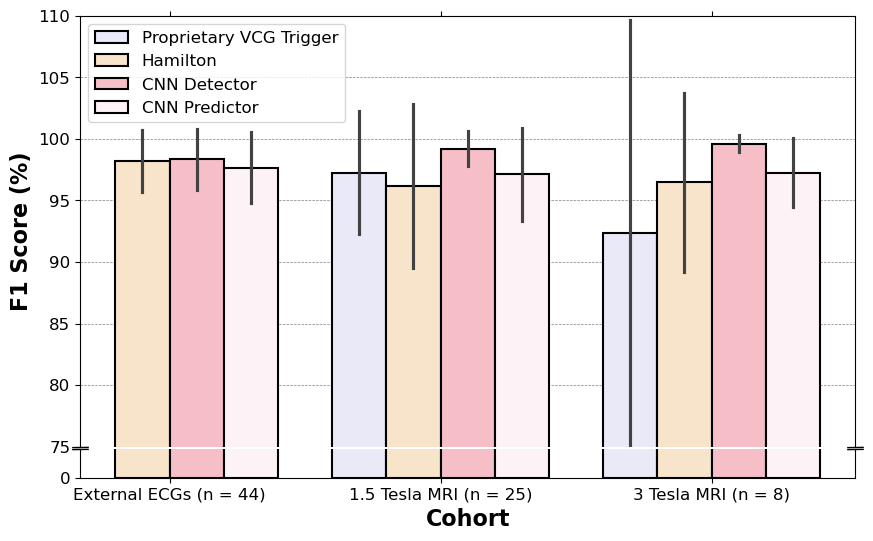

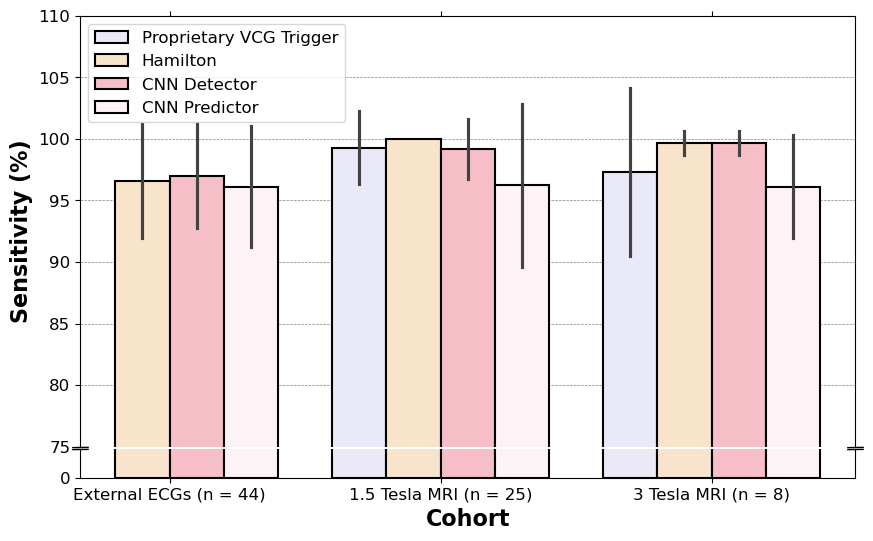

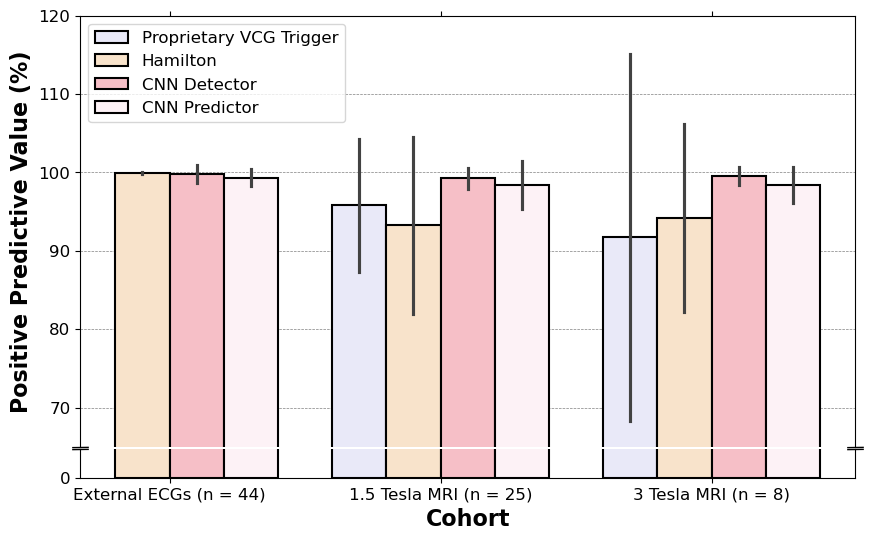

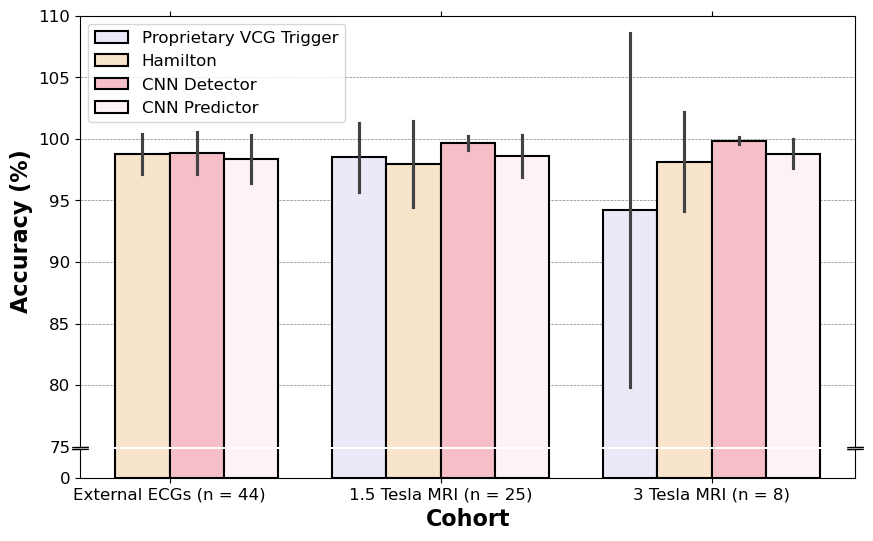

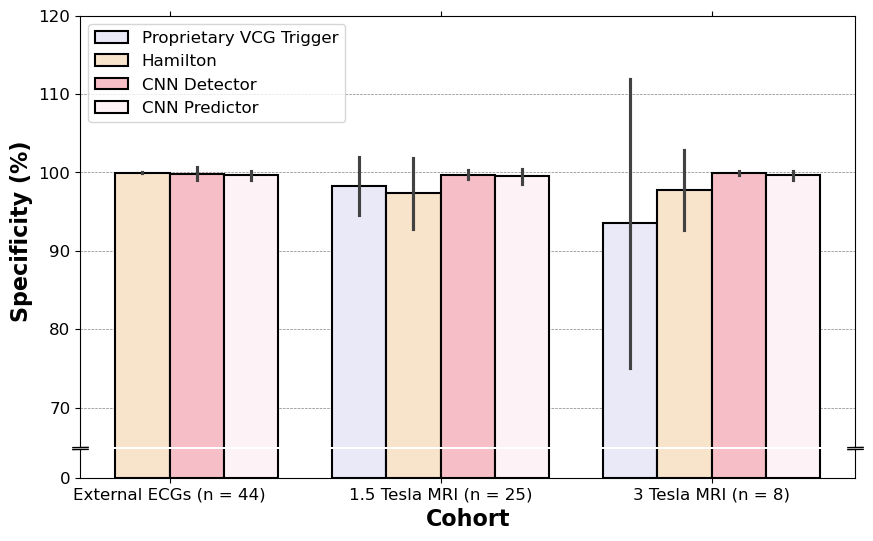

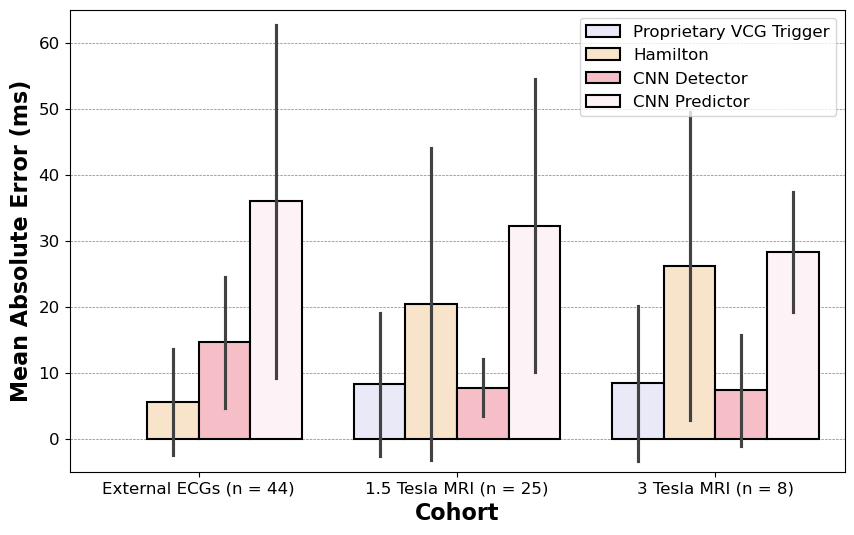

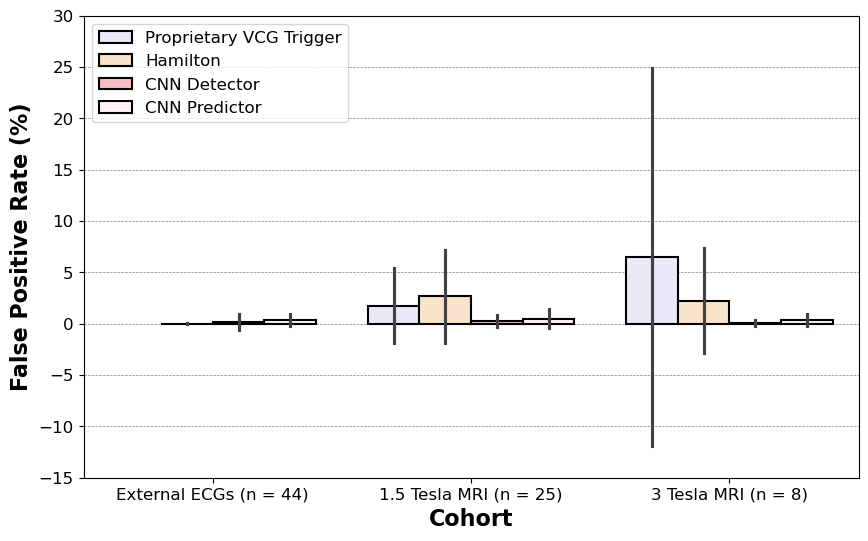

In [5]:
methods = ['Proprietary VCG Trigger', 'Hamilton', 'CNN Detector', 'CNN Predictor']
cohorts = ['External ECGs (n = 44)','1.5 Tesla MRI (n = 25)','3 Tesla MRI (n = 8)']

# Define a custom color palette
colors = ["lavender","bisque","lightpink","lavenderblush"]
palette = sns.color_palette(colors)

metrics = ['F1 Score (%)', 'Sensitivity (%)', 'Positive Predictive Value (%)', 'Accuracy (%)', 'Specificity (%)']
for metric in metrics:
    fig, (ax, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6), gridspec_kw={'height_ratios': [15, 1]})
    
    # Plot the same data on both axes
    sns.barplot(data=results_dataframe, x='Cohort', y=metric, hue='R-Peak Detection Method', errorbar = 'sd', 
                ax=ax, order=cohorts, hue_order=methods, palette=palette, edgecolor='black', linewidth=1.5)
    sns.barplot(data=results_dataframe, x='Cohort', y=metric, hue='R-Peak Detection Method', errorbar = 'sd', 
                ax=ax2, order=cohorts, hue_order=methods, palette=palette, edgecolor='black', linewidth=1.5)

    # Set y-axis limits
    if metric == 'Positive Predictive Value (%)' or metric == 'Specificity (%)':
        ax.set_ylim(65, 120)
    else:  
        ax.set_ylim(75, 110)  # Upper plot
    ax2.set_ylim(0, 1)    # Lower plot

    # Remove legend title
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='', loc='upper left', fontsize=12)

    # Bold the x and y-axis labels
    ax2.set_xlabel(ax2.get_xlabel(), fontweight='bold', fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold', fontsize=16)
    
    # Remove legend and y-axis label from the bottom plot
    ax2.legend().remove()
    ax2.set_ylabel('')

    # Set x-ticks and y-ticks
    ax.tick_params(axis='x', labelsize=12)  # Adjust x-ticks font size
    ax.tick_params(axis='y', labelsize=12)  # Adjust y-ticks font size
    ax2.tick_params(axis='x', labelsize=12)  # Repeat for the bottom subplot
    ax2.tick_params(axis='y', labelsize=12)
    ax2.set_yticks([0])  # Show only '0' as y-tick label for the bottom subplot

    # Add diagonal lines to indicate the break
    d = .015  # Size of the diagonal lines
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax.plot([0, 1], [0, 0], transform=ax.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    # Hide the spines between ax and ax2
    ax.spines['bottom'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax.xaxis.tick_top()
    ax.tick_params(labeltop=False)  # Don't put tick labels at the top
    ax2.xaxis.tick_bottom()

    # Add y-axis grid lines and set them to be behind bars for both subplots
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray')
    ax.set_axisbelow(True)
    ax2.yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray')
    ax2.set_axisbelow(True)

    # Decrease the spacing between the plots
    plt.subplots_adjust(hspace=0.01)  # Adjust the value as needed
    plt.xticks(rotation=0)
    plt.show()
    
    # Download each figure as a png file in a new folder called 'Figures'
    if os.path.exists(f'./figures/{metric}'):
        fig.savefig(f'./figures/{metric}/{metric}.png', bbox_inches='tight')
    else:
        os.makedirs(f'./figures/{metric}')
        fig.savefig(f'./figures/{metric}/{metric}.png', bbox_inches='tight')

metrics2 = ['Mean Absolute Error (ms)', 'False Positive Rate (%)']
for metric in metrics2:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the data
    sns.barplot(data=results_dataframe, x='Cohort', y=metric, hue='R-Peak Detection Method',errorbar= 'sd',
                ax=ax, order=cohorts, hue_order=methods, palette=palette, edgecolor='black', linewidth=1.5)

    # Remove legend title
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, title='', fontsize=12)

    # Bold the x and y-axis labels
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold', fontsize=16)

    # Increase font size of x-ticks and y-ticks
    ax.tick_params(axis='x', labelsize=12)  # Adjust x-ticks font size
    ax.tick_params(axis='y', labelsize=12)  # Adjust y-ticks font size

    #set ylims 
    if metric == 'Mean Absolute Error (ms)':
        ax.set_ylim(-5, 65)
    else: 
        ax.set_ylim(-15, 30)

    # Add y-axis grid lines
    plt.gca().yaxis.grid(True, linestyle='--', linewidth=0.5, color='gray')
    plt.gca().set_axisbelow(True)
    plt.xticks(rotation=0)
    plt.show()

    # Download each figure as a png file in a new folder called 'Figures'
    if os.path.exists(f'./figures/{metric}'):
        fig.savefig(f'./figures/{metric}/{metric}.png', bbox_inches='tight')
    else:
        os.makedirs(f'./figures/{metric}')
        fig.savefig(f'./figures/{metric}/{metric}.png', bbox_inches='tight')

# ANOVA Analysis

In [ ]:
metrics = ['F1 Score (%)', 'Sensitivity (%)', 'Positive Predictive Value (%)', 'Accuracy (%)', 'Specificity (%)', 'Mean Absolute Error (ms)', 'False Positive Rate (%)']
methods = ['Proprietary VCG Trigger', 'Hamilton', 'CNN Detector', 'CNN Predictor']
cohorts = ['External ECGs (n = 44)','1.5 Tesla MRI (n = 25)','3 Tesla MRI (n = 8)']

for metric in metrics:
    # For each metric perform ANOVA with Tukey HSD Test based on the cohort
    for cohort in cohorts:
        results_cohort = pd.DataFrame()
        results_cohort = results_dataframe[results_dataframe['Cohort'] == cohort]
        for metric in metrics:
            tukey = multi.pairwise_tukeyhsd(endog=results_cohort[metric],
                                            groups=results_cohort['R-Peak Detection Method'],
                                            alpha=0.05)

            # Plotting the Tukey HSD results
            fig = tukey.plot_simultaneous(xlabel=metric, ylabel='R-Peak Detection Method', figsize=(12, 3));
            plt.title(f"ANOVA with Tukey HSD Test, {metric}, {cohort}");
            plt.show();

            # Download each figure as a png file in a new folder called 'Figures'
            if os.path.exists(f'./figures/{metric}/cohort'):
                fig.savefig(f'./figures/{metric}/cohort/ANOVA_{metric}_{cohort}.png', bbox_inches='tight')
            else:
                os.makedirs(f'./figures/{metric}/cohort/')
                fig.savefig(f'./figures/{metric}/cohort/ANOVA_{metric}_{cohort}.png', bbox_inches='tight')
            
    # For each metric perform ANOVA with Tukey HSD Test based on the method
    for method in methods:
        results_method = pd.DataFrame()
        results_method = results_dataframe[results_dataframe['R-Peak Detection Method'] == method]
        for metric in metrics:
            tukey = multi.pairwise_tukeyhsd(endog=results_method[metric],
                                            groups=results_method['Cohort'],
                                            alpha=0.05)

            # Plotting the Tukey HSD results
            fig = tukey.plot_simultaneous(xlabel=metric, ylabel='Cohort', figsize=(12, 3));
            plt.title(f"ANOVA with Tukey HSD Test, {metric}, {method}");
            plt.show();

            # Download each figure as a png file in a new folder called 'Figures'
            if os.path.exists(f'./figures/{metric}/method'):
                fig.savefig(f'./figures/{metric}/method/ANOVA_{metric}_{method}.png', bbox_inches='tight')
            else:
                os.makedirs(f'./figures/{metric}/method')
                fig.savefig(f'./figures/{metric}/method/ANOVA_{metric}_{method}.png', bbox_inches='tight')